In [29]:
import numpy as np
import matplotlib.pyplot as plt
import qnm

In [30]:
plt.rcParams['figure.max_open_warning'] = 0
    
plt.rcParams['mathtext.fontset']  = 'stix'
plt.rcParams['font.family']       = 'STIXGeneral'

plt.rcParams['font.size']         = 14
plt.rcParams['axes.linewidth']    = 1
plt.rcParams['axes.labelsize']    = plt.rcParams['font.size']
plt.rcParams['axes.titlesize']    = 1.5*plt.rcParams['font.size']
plt.rcParams['legend.fontsize']   = plt.rcParams['font.size']
plt.rcParams['xtick.labelsize']   = plt.rcParams['font.size']
plt.rcParams['ytick.labelsize']   = plt.rcParams['font.size']
plt.rcParams['xtick.major.size']  = 3
plt.rcParams['xtick.minor.size']  = 3
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.major.size']  = 3
plt.rcParams['ytick.minor.size']  = 3
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.width'] = 1

plt.rcParams['legend.frameon']             = False
plt.rcParams['legend.loc']                 = 'center left'
plt.rcParams['contour.negative_linestyle'] = 'solid'

$$A_{\bar{h}}(\tau)=\left(\frac{c_1^A}{1+\exp(-c_2^A\tau+c_3^A)}+c_4^A\right)^{\frac{1}{c_5^A}}$$
$$\phi_{\bar{h}}(\tau)= -c_1^{\phi}\ln\left(\frac{1+c_3^{\phi}\exp(-c_2^{\phi}\tau)+c_4^{\phi}\exp(-2c_2^{\phi}\tau)}{1+c_3^{\phi}+c_4^{\phi}}\right)$$

Amplitudes:
- $c_1^A=\frac{c_5^A\alpha_1}{c_2^A}(A_{22}^{\text{mrg}})^{c_5^A}\exp(-c_3^A)(1+\exp(c_3^A))^2$
- $c_2^A$ *free*
- $c_3^A$ *free*
- $c_4^A=(A_{22}^{\text{mrg}})^{c_5^A}-\frac{c_1^A}{1+\exp(c_3^A)}$
- $c_5^A=-\frac{\ddot{A}_{22}^{\text{mrg}}}{A_{22}^{\text{mrg}}\alpha_1^2}+\frac{c_2^A}{\alpha_1}\frac{\exp(c_3^A)-1}{\exp(c_3^A)+1}$

Phases:
- $c_1^{\phi}=\frac{1+c_3^{\phi}+c_4^{\phi}}{c_2^{\phi}(c_3^{\phi}+2c_4^{\phi})}\Delta\omega$ 
- $c_2^{\phi}$ *free*
- $c_3^{\phi}$ *free*
- $c_4^{\phi}$ *free*

In [31]:
q=0.9
nu=q/(1+q)**2
Mf=0.948820101
af=0.6850951607

In [32]:
A_22_mrg = 0.4025928998603003*nu
omg_peak = 0.367888631052355*nu
A_22_mrg_ddot = -0.0008442826061478*nu

In [33]:
alp1_22_0 = 0.08896
b_1_22, b_2_22, b_3_22 = -1.90036, 0.86200, 0.0384893
c_1_22, c_2_22, c_3_22 = -1.87933, 0.88062, 0.
alpha_1 = alp1_22_0*(1 + b_1_22*af + b_2_22*af**2 + b_3_22*af**3)/(1 + c_1_22*af + c_2_22*af**2 + c_3_22*af**3)

In [34]:
alp21_22_0 = 0.184953
b_1_22, b_2_22, b_3_22 = -1.89397, 0.88126, 0.0130256
c_1_22, c_2_22, c_3_22 = -1.83901, 0.84162, 0.
alpha_21 = alp21_22_0*(1 + b_1_22*af + b_2_22*af**2 + b_3_22*af**3)/(1 + c_1_22*af + c_2_22*af**2 + c_3_22*af**3)
alpha_2 = alpha_21 + alpha_1

In [35]:
omg1_22_0 = 0.373672
b_1_22, b_2_22, b_3_22 = -1.5367, 0.5503, 0.
c_1_22, c_2_22, c_3_22 = -1.8700, 0.9848, -0.10943
omega_1 = omg1_22_0*(1 + b_1_22*af + b_2_22*af**2 + b_3_22*af**3)/(1 + c_1_22*af + c_2_22*af**2 + c_3_22*af**3)
delta_omega = (omega_1 - Mf*omg_peak)*10

In [36]:
def nc_amplitude(c2A, c3A, tau):
    c5A = -A_22_mrg_ddot / (A_22_mrg * alpha_1**2) + c2A / alpha_1 * (np.exp(c3A) - 1) / (np.exp(c3A) + 1)
    c1A = c5A * alpha_1 / c2A * A_22_mrg**c5A * np.exp(-c3A) * (1 + np.exp(c3A))**2
    c4A = A_22_mrg**c5A - c1A / (1 + np.exp(c3A))
    amp = (c1A / (1 + np.exp(-c2A * tau + c3A)) + c4A)**(1 / c5A)
    return amp 

In [37]:
def nc_phase(c2P, c3P, c4P, tau):
    c1P = (1 + c3P + c4P) / (c2P * (c3P + 2 * c4P)) * delta_omega
    phi = -c1P * np.log((1 + c3P * np.exp(-c2P * tau) + c4P * np.exp(-2 * c2P * tau)) / (1 + c3P + c4P))
    return phi

$$h(t)=A_{\bar{h}}(\tau)\exp(i\phi_{\bar{h}}(\tau))$$
$$f(t)=\dot{\phi}_{\bar{h}}(\tau)$$

In [38]:
def instantaneous_frequency(phi, tau):
    dphi = np.gradient(phi, tau)
    return dphi

In [39]:
c3A = -2.528748566343
c3p = 3.401284144614
c4p = 6.292701358937
c2A = 0.170535630360
c2p = 0.138504854006

c3A_err_p, c3A_err_m = 0.168716738905, 0.167471514847
c3p_err_p, c3p_err_m = 0.756978517502, 0.713312118887
c4p_err_p, c4p_err_m = 0.614174487082, 0.573243511193
c2A_err_p, c2A_err_m = 0.003578179298, 0.003402293947
c2p_err_p, c2p_err_m = 0.007927808375, 0.008332335625

In [40]:
tau = np.linspace(0, 100, 1000)
amp = nc_amplitude(c2A, c3A, tau)
phase = nc_phase(c2p, c3p, c4p, tau)
freq = instantaneous_frequency(phase, tau)

amp_p, amp_m = nc_amplitude(c2A + c2A_err_p, c3A + c3A_err_p, tau), nc_amplitude(c2A - c2A_err_m, c3A - c3A_err_m, tau)
phase_p, phase_m = nc_phase(c2p + c2p_err_p, c3p + c3p_err_p, c4p + c4p_err_p, tau), nc_phase(c2p - c2p_err_m, c3p - c3p_err_m, c4p - c4p_err_m, tau)
freq_p, freq_m = instantaneous_frequency(phase_p, tau), instantaneous_frequency(phase_m, tau)

In [41]:
re = amp * np.cos(phase)
im = amp * np.sin(phase)

re_p = amp_p * np.cos(phase_p)
im_p = amp_p * np.sin(phase_p)
re_m = amp_m * np.cos(phase_m)
im_m = amp_m * np.sin(phase_m)

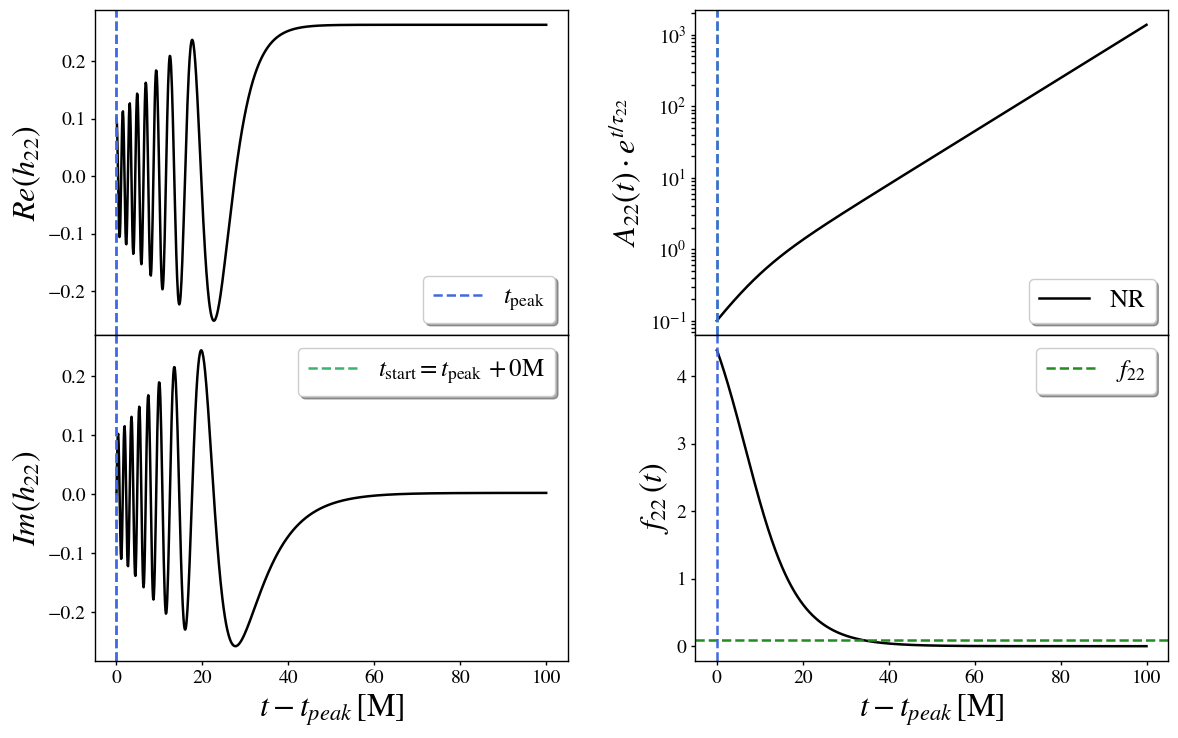

In [42]:
t_NR = tau
t_peak = 0
tM_start = 0

NR_r = re
NR_i = im
NR_amp = amp
NR_f = freq

label_data = 'h_{22}'

COL = {
    'NR': 'k',
    'model': '#cc0033',
    't_start': 'mediumseagreen',
    't_peak': 'royalblue',
    'f_overt': 'darkorange',
    'f_ring': 'forestgreen',
}

alpha_std = 1.0
alpha_med = 0.8

LS = {
    't': '--',
    'f': '--',
}

LW = {
    'small': 0.5,
    'medium': 1.2,
    'std': 1.8,
    'large': 2.2,
}

FONTS = {
    'legend': 18,
    'labels': 23,
}

omega, _, _ = qnm.modes_cache(s=-2, l=2, m=2, n=0)(a=np.abs(af))
f_rd_fundamental = (np.real(omega) / Mf) / (2.0 * np.pi)
tau_rd_fundamental = -1.0 / (np.imag(omega)) * Mf

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
ax1, ax2, ax3, ax4 = axes.flat

plot_std = dict(c=COL['NR'], lw=LW['std'], alpha=alpha_std, ls='-')
vline_std = dict(lw=LW['std'], alpha=alpha_std, ls=LS['t'])
vline_peak = dict(lw=LW['std'], alpha=alpha_std, ls=LS['t'])
ax2_semilogy_kwargs = dict(label=r'$\mathrm{NR}$', c=COL['NR'], lw=LW['std'],
                           alpha=alpha_std, ls='-')

ax1.plot(t_NR - t_peak, NR_r, **plot_std)
ax1.axvline(tM_start, c=COL['t_start'], **vline_std)
ax1.axvline(0.0, label=r'$t_{\rm peak}$', c=COL['t_peak'], **vline_peak)
ax1.set_ylabel(r'$\mathit{Re}(%s)$' % (label_data,), fontsize=FONTS['labels'])

ax3.plot(t_NR - t_peak, NR_i, **plot_std)
ax3.axvline(tM_start,
            label=r'$t_{\rm start} = t_{\rm peak} \, + %d \mathrm{M}$' % tM_start,
            c=COL['t_start'], **vline_std)
ax3.axvline(0.0, c=COL['t_peak'], **vline_peak)
ax3.set_ylabel(r'$\mathit{Im}(%s)$' % (label_data,), fontsize=FONTS['labels'])
ax3.set_xlabel(r'$t - t_{peak} \, [\mathrm{M}]$', fontsize=FONTS['labels'])

ax2.semilogy(t_NR - t_peak,
             NR_amp * np.exp((t_NR - t_peak) / tau_rd_fundamental),
             **ax2_semilogy_kwargs)
ax2.axvline(tM_start, c=COL['t_start'], **vline_std)
ax2.axvline(0.0, c=COL['t_peak'], **vline_peak)
ax2.set_ylabel(r'$\mathit{A_{22}(t)} \cdot e^{t/\tau_{22}}$',
               fontsize=FONTS['labels'])

ax4.plot(t_NR - t_peak, NR_f, **plot_std)
ax4.axhline(f_rd_fundamental, label=r'$\mathit{f_{22}}$', c=COL['f_ring'],
            lw=LW['std'], alpha=alpha_std, ls=LS['f'])
ax4.axvline(0.0, c=COL['t_peak'], **vline_peak)
ax4.set_xlabel(r'$t - t_{peak} \, [\mathrm{M}]$', fontsize=FONTS['labels'])
ax4.set_ylabel(r'$\mathit{f_{22}\,(t)}$', fontsize=FONTS['labels'])

plt.rcParams['legend.frameon'] = True
for ax in (ax1, ax2, ax3, ax4):
    ax.legend(loc='best', fontsize=FONTS['legend'], shadow=True)

ax1.set_xlim(ax3.get_xlim())
ax1.set_xticklabels([])
ax2.set_xlim(ax4.get_xlim())
ax2.set_xticklabels([])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0, wspace=0.27)
plt.show()